In [2]:
import arviz as az
import math
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
import xarray as xr
from causalgraphicalmodels import CausalGraphicalModel

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
hdi_fill_args = { 'color': 'gray', 'alpha': 0.2 }

__Probabilistic Programming. Wasowski. Pardo. IT University of Copenhagen__

This file contains the list of exercises for the week, as well as any related code.

## Exercises

The exercises for this week are: __all exercises__ from Chapter 5, McElreath, with exceptions noted below. Some remarks:
* __5M4__ is the first programming exercises. All the questions before it are about math on paper, or discussion (this remark is here to make sure you don't get into large open coding projects).
* Exercise __5M4__ requires finding a dataset with percent of population of members of Church of Jesus Christ of Latter-day Saints (LDS).  Below we provide this dataset and add it to the loaded `WaffleDivorce.csv` data set, to get you started more efficiently.

In [3]:
# 5M1
"""
Invent your own example of a spurious correlation. An outcome variable should be correlated
with both predictor variables. But when both predictors are entered in the same model, the correlation
between the outcome and one of the predictors should mostly vanish (or at least be greatly reduced).
"""

# Generate data
with pm.Model() as model:
    N = 100
    x1 = pm.Normal('x1', mu=0, sigma=1, shape=N)
    x2 = pm.Normal('x2', mu=0, sigma=1, shape=N)
    y = pm.Normal('y', mu=0.5*x1 + 0.5*x2, sigma=1, shape=N)
    trace = pm.sample(100, tune=10)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [x1, x2, y]


Output()

Sampling 4 chains for 10 tune and 100 draw iterations (40 + 400 draws total) took 48 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x1'}>],
       [<Axes: title={'center': 'x2'}>, <Axes: title={'center': 'x2'}>],
       [<Axes: title={'center': 'y'}>, <Axes: title={'center': 'y'}>]],
      dtype=object)

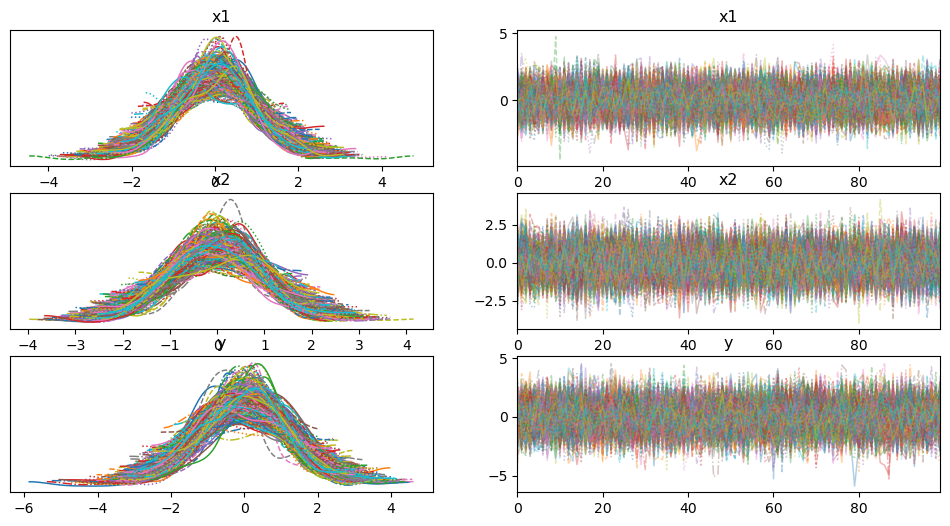

In [6]:
az.plot_trace(trace)

In [14]:
data = pd.read_csv("WaffleDivorce.csv", delimiter=";")
data["pct_LDS"] = np.asarray([0.75, 4.53, 6.18, 1, 2.01, 2.82, 0.43, 0.55, 0.38, 0.75, 0.82, 5.18, 26.35, 0.44, 0.66, 0.87, 1.25, 0.77, 0.64, 0.81,
                              0.72, 0.39, 0.44, 0.58, 0.72, 1.14, 4.78, 1.29, 0.61, 0.37, 3.34, 0.41, 0.82, 1.48, 0.52, 1.2, 3.85, 0.4, 0.37, 0.83, 1.27, 0.75,
                              1.21, 67.97, 0.74, 1.13, 3.99, 0.92, 0.44, 11.5])
data.head()

,Location,Loc,Population,MedianAgeMarriage,Marriage,Marriage SE,Divorce,Divorce SE,WaffleHouses,South,Slaves1860,Population1860,PropSlaves1860,pct_LDS
0,Alabama,AL,4.78,25.3,20.2,1.27,12.7,0.79,128,1,435080,964201,0.45,0.75
1,Alaska,AK,0.71,25.2,26.0,2.93,12.5,2.05,0,0,0,0,0.00,4.53
2,Arizona,AZ,6.33,25.8,20.3,0.98,10.8,0.74,18,0,0,0,0.00,6.18
3,Arkansas,AR,2.92,24.3,26.4,1.70,13.5,1.22,41,1,111115,435450,0.26,1.00
4,California,CA,37.25,26.8,19.1,0.39,8.0,0.24,0,0,0,379994,0.00,2.01


In [8]:
# 5M4
"""
In the divorce data, States with high numbers of members of the Church of Jesus Christ of
Latter-day Saints (LDS) have much lower divorce rates than the regression models expected. Find a
list of LDS population by State and use those numbers as a predictor variable, predicting divorce rate
using marriage rate, median age at marriage, and percent LDS population (possibly standardized).
You may want to consider transformations of the raw percent LDS variable.
"""

with pm.Model() as model:
    N = data.shape[0]
    pct_LDS = pm.Normal('pct_LDS', mu=data["pct_LDS"].mean(), sigma=data["pct_LDS"].std(), shape=N)
    marriage = pm.Normal('marriage', mu=data["Marriage"].mean(), sigma=data["Marriage"].std(), shape=N)
    age = pm.Normal('age', mu=data["MedianAgeMarriage"].mean(), sigma=data["MedianAgeMarriage"].std(), shape=N)
    y = pm.Normal('y', mu=marriage + age + pct_LDS, sigma=1, shape=N)
    trace = pm.sample(100, tune=10)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pct_LDS, marriage, age, y]


Output()

Sampling 4 chains for 10 tune and 100 draw iterations (40 + 400 draws total) took 340 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [16]:
def Standardize(x):
    return (x - x.mean()) / x.std()

xdata = data.to_xarray()
xdata["Divorce_std"] = Standardize(xdata["Divorce"])
xdata["Marriage_std"] = Standardize(xdata["Marriage"])
xdata["MedianAgeMarriage_std"] = Standardize(xdata["MedianAgeMarriage"])
xdata["pct_LDS_std"] = Standardize(xdata["pct_LDS"])



In [17]:
marriage_data = xdata['Marriage_std'].values
age_data = xdata['MedianAgeMarriage_std'].values
lds_data = xdata['pct_LDS_std'].values

with pm.Model() as Exercise5M4:
    a = pm.Normal('a', mu=0, sigma=0.2)
    bA = pm.Normal('bA', mu=0, sigma=0.5)
    bM = pm.Normal('bM', mu=0, sigma=0.5)
    bL = pm.Normal('bL', mu=0, sigma=1.0)
    sigma = pm.Exponential('sigma', lam=1)
    
    # X = pm.Data('X', xdata, mutable=True)
    
    # mu = pm.Deterministic('mu', a + bM*X["Marriage_std"] + bA*X["MedianAgeMarriage_std"] + bL*X["pct_LDS_std"])
    
    Marriage = pm.Data('Marriage', marriage_data, mutable=True)
    Age = pm.Data('Age', age_data, mutable=True)
    LDS = pm.Data('LDS', lds_data, mutable=True)

    mu = pm.Deterministic('mu', a + bM*Marriage + bA*Age + bL*LDS)
    
    D = pm.Normal('D', mu=mu, sigma=sigma, observed=xdata["Divorce_std"])
    Exercise5M4_idata = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)
    Exercise5M4_idata.extend(pm.sample(random_seed=RANDOM_SEED))
    

c:\Users\patr7\anaconda3\envs\prpro-2025\Lib\site-packages\pymc\data.py:440: FutureWarning: Data is now always mutable. Specifying the `mutable` kwarg will raise an error in a future release
  warnings.warn(
Sampling: [D, a, bA, bL, bM, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bA, bM, bL, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 192 seconds.


In [ ]:
pm.model_to_graphviz(Exercise5M4)

In [ ]:
az.summary(Exercise5M4_idata)

* __5M5__ and __5H1__, are a no-code exercises again. (Well. CasualGraphicalModels can help with __5H1__)

* I found the combination of __5H1__ and __5H2__ particularly useful for learning about counterfactuals, because the causal model that we are working with is quite different from the one in the class. It makes it much more clear that the counterfactual predictions should be made from a causal model, and the Bayesian hierarchical model we are using, should follow the same structure as the causal model.  As a hint, this is the model I used:

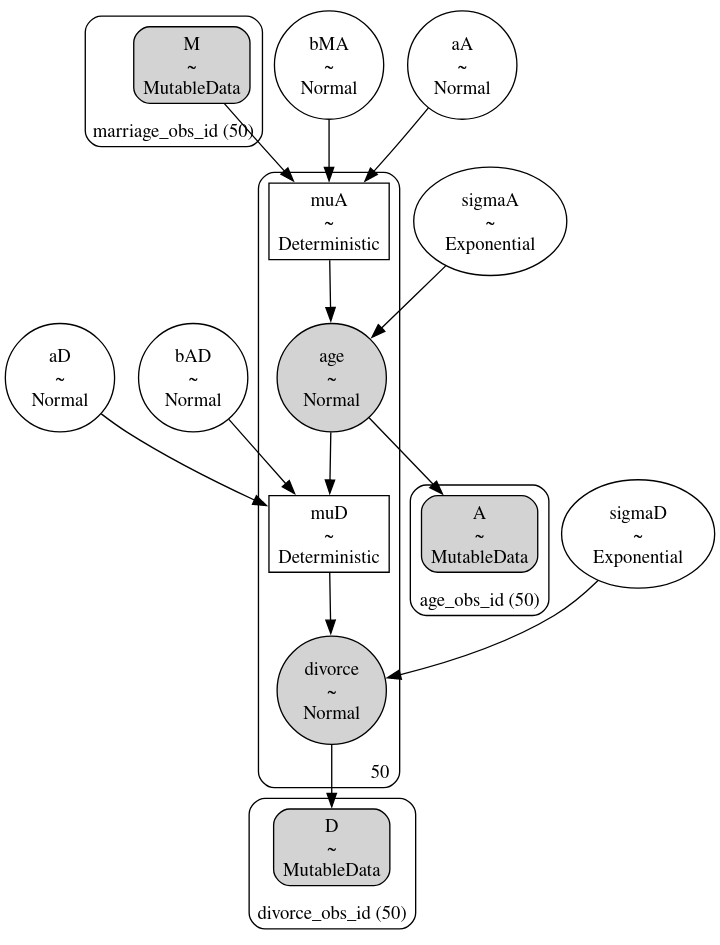

* To estimate the effect of doublig/halving one variable (M both in 5H2 and 5H3) we need to choose a particular value of M. A mean is a good choice.  Then we do a normal prior prediction, but just with two points. The mean, and double that, or the mean and half that (for the corresponding exercises). One needs to remember to standardize the two points.

In [20]:
# 5H2
"""
Assuming that the DAG for the divorce example is indeed M → A → D, fit a new model and
use it to estimate the counterfactual effect of halving a State’s marriage rate M. Use the counterfactual
example from the chapter (starting on page 140) as a template.
"""

with pm.Model() as Exercise5H2:
    M = pm.MutableData('M', marriage_data)
    A = pm.MutableData('A', age_data)
    D = pm.MutableData('D', xdata["Divorce_std"].values)
    
    # Priors
    sigmaD = pm.Exponential('sigmaD', lam=1)
    sigmaA = pm.Exponential('sigmaA', lam=1)
    bAD = pm.Normal('bAD', mu=0, sigma=0.5)
    bAM = pm.Normal('bAM', mu=0, sigma=0.5)
    aD = pm.Normal('aD', mu=0, sigma=0.2)
    aA = pm.Normal('aA', mu=0, sigma=0.2)
    
    # M -> A
    muA = pm.Deterministic('muA', aA + bAM*M)
    age = pm.Normal('A_', mu=muA, sigma=sigmaA, observed=A)
    
    # A -> D
    muD = pm.Deterministic('muD', aD + bAD*age)
    divorce = pm.Normal('D_', mu=muD, sigma=sigmaD, observed=D)
    
    # Exercise5H2_idata = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)
    # Exercise5H2_idata.extend(pm.sample(random_seed=RANDOM_SEED))
    Exercise5H2_idata = pm.sample(random_seed=RANDOM_SEED)

c:\Users\patr7\anaconda3\envs\prpro-2025\Lib\site-packages\pymc\data.py:321: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigmaD, sigmaA, bAD, bAM, aD, aA]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 163 seconds.


In [21]:
az.summary(Exercise5H2_idata, var_names=["aD", "aA", "bAD", "bAM", "sigmaD", "sigmaA"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
aD,-0.001,0.100,-0.188,0.188,0.002,0.001,3850.0,2847.0,1.0
aA,0.000,0.091,-0.173,0.173,0.001,0.001,5795.0,3350.0,1.0
bAD,-0.568,0.116,-0.787,-0.354,0.002,0.001,4886.0,3269.0,1.0
bAM,-0.691,0.099,-0.877,-0.504,0.001,0.001,4751.0,3234.0,1.0
sigmaD,0.829,0.086,0.686,1.001,0.001,0.001,4909.0,3155.0,1.0
sigmaA,0.718,0.074,0.590,0.865,0.001,0.001,5159.0,2981.0,1.0


In [22]:
M_seq = np.linspace(-3, 3, 42)

In [23]:
with Exercise5H2:
    pm.set_data({'M': M_seq, 'A': np.zeros_like(M_seq), 'D': np.zeros_like(M_seq)})  # set A and D to zero
    pm.sample_posterior_predictive(
        Exercise5H2_idata,
        predictions=True,
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

Sampling: [A_, D_]


Output()

NameError: name 'M_seq' is not defined

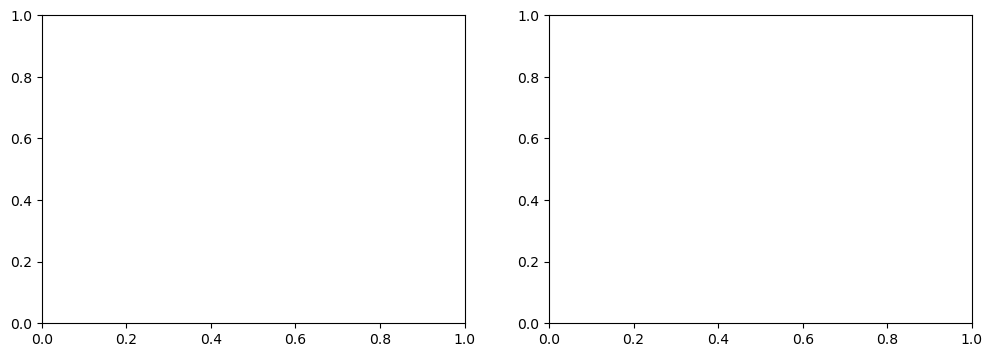

In [ ]:
# find more of the code from the slides
_, ax = plt.subplots(1, 2, figsize=(12, 4))
az.plot_hdi(M_seq, Exercise5H2_idata.posterior["muA"], ax=ax[0], fill_kwargs=hdi_fill_args)
az.plot_hdi(M_seq, Exercise5H2_idata.posterior["muD"], ax=ax[1], fill_kwargs=hdi_fill_args)
ax[0].set_xlabel("Marriage rate")

ax[0].set_ylabel("Median age at marriage")
ax[1].set_ylabel("Divorce rate")

plt.show()

* Similarly, this is the PyMC model structure I arrived at for Ex. __5H3__:

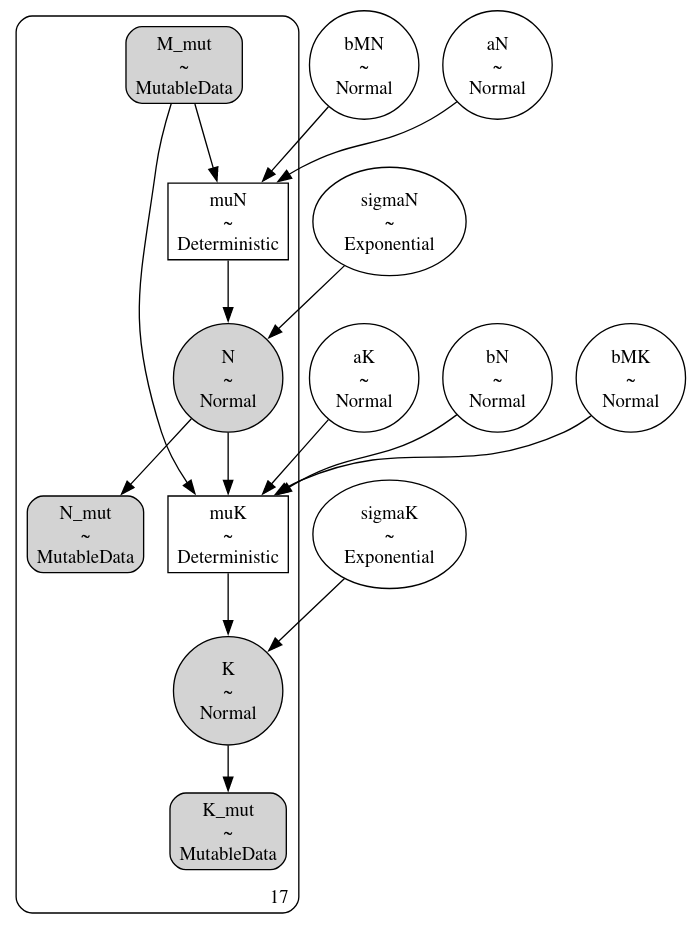

* Skip the last exercise __5H5__, unless excited about it. 